In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import os
import numpy as np
import gc
from pathlib import Path

In [4]:
#---CONFIG---
DATA_RAW = Path("../data/raw")
OUTPUT = Path("../outputS/eda")
OUTPUT.mkdir(exist_ok=True, parents=True)

sns.set_theme(style="whitegrid")

In [6]:
#---LOAD DATA---
calendar = pd.read_csv(DATA_RAW / "calendar.csv")
sales= pd.read_csv(DATA_RAW / "sales_train_evaluation.csv")
prices = pd.read_csv(DATA_RAW / "sell_prices.csv")

print(calendar.shape, sales.shape, prices.shape)

(1969, 14) (30490, 1947) (6841121, 4)


In [7]:
#--MELT--
id_cols =["id","item_id", "dept_id", "cat_id", "store_id", "state_id"]
day_cols =[ c for c in sales.columns if c not in id_cols]

df = sales.melt(
    id_vars=id_cols, 
    value_vars=day_cols, 
    var_name="d", 
    value_name="sales"
)

print(df.shape)

(59181090, 8)


In [8]:
#---MERGE---

# Merge calendar
df = df.merge(
    calendar[["date", "wm_yr_wk", "weekday", "wday", 
              "month", "year", "d", "event_name_1", 
              "event_type_1", "event_name_2", "event_type_2", 
              "snap_CA", "snap_TX", "snap_WI"]],
    on="d", how="left"
)
df["date"] = pd.to_datetime(df["date"])

# Merge prices
df = df.merge(
    prices[["store_id", "item_id", "wm_yr_wk", "sell_price"]],
    on=["store_id", "item_id", "wm_yr_wk"],
    how="left"
)


print(df.dtypes)
print(df.shape)

id                      object
item_id                 object
dept_id                 object
cat_id                  object
store_id                object
state_id                object
d                       object
sales                    int64
date            datetime64[ns]
wm_yr_wk                 int64
weekday                 object
wday                     int64
month                    int64
year                     int64
event_name_1            object
event_type_1            object
event_name_2            object
event_type_2            object
snap_CA                  int64
snap_TX                  int64
snap_WI                  int64
sell_price             float64
dtype: object
(59181090, 22)


In [ ]:
#---SALES MISSING VALUES---
missing = df[["sales", "sell_price"]].isna().mean() * 100
print(missing)

sales          0.000000
sell_price    20.782674
dtype: float64


## Nhận xét missing value
không có missing value trong cột sales . tất cả giá trị trong cột sales đã được fill .
cột sell_price có ~ 20.78% missing value. Cần forward - fill trong bước clean .

In [14]:
#---ZERO SALES RATIO---
zero_sales_ratio = (df["sales"] == 0).mean() * 100
print(f"Zero Sales Ratio: {zero_sales_ratio:.2f}%")
zero_by_store = df.groupby("store_id")["sales"].apply(lambda x: (x == 0).mean() * 100)
print(zero_by_store)

Zero Sales Ratio: 68.00%
store_id
CA_1    63.759049
CA_2    68.810291
CA_3    59.399768
CA_4    71.999519
TX_1    70.714074
TX_2    66.314172
TX_3    69.715073
WI_1    68.754056
WI_2    70.480047
WI_3    70.031610
Name: sales, dtype: float64


## Nhận xét Zero Sales

- Toàn bộ dataset có **68% ngày có sales = 0** — đây là tỷ lệ rất cao,
  cho thấy phần lớn series thuộc loại **intermittent demand**
  (zero_ratio >= 0.3 theo spec)

- Tỷ lệ zero dao động từ **59% (CA_3)** đến **72% (CA_4)** giữa các store,
  không có store nào đặc biệt khác biệt so với mức trung bình

- CA_3 là store có tỷ lệ zero thấp nhất (~59%) → hàng hóa bán đều hơn
  các store còn lại

- Giữ nguyên toàn bộ zero sales, không xóa, không fill —
  đây là tín hiệu thực tế của intermittent demand,
  cần thiết để tính zero_ratio và phân loại demand_type ở bước profiling

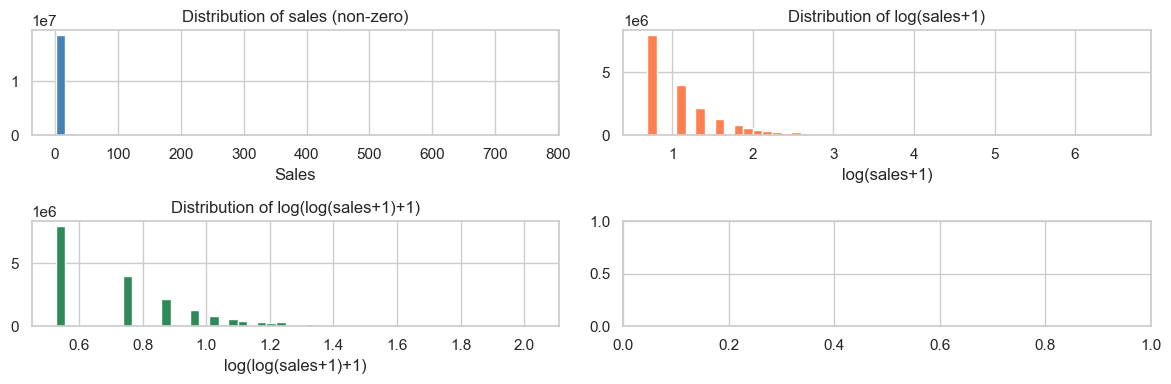

In [18]:
#---DISTRIBUTION---
fig, axes = plt.subplots(2,2 , figsize=(12, 4))

# Non - zero 
nonzero = df[df["sales"] > 0]["sales"]
axes[0][0].hist(nonzero, bins=50, color="steelblue", edgecolor="white")
axes[0][0].set_title("Distribution of sales (non-zero)")
axes[0][0].set_xlabel("Sales")

# Log scale
axes[0][1].hist(np.log1p(nonzero), bins=50, color="coral", edgecolor="white")
axes[0][1].set_title("Distribution of log(sales+1)")
axes[0][1].set_xlabel("log(sales+1)")

# log_log scale
axes[1][0].hist(np.log1p(np.log1p(nonzero)), bins=50, color="seagreen", edgecolor="white")
axes[1][0].set_title("Distribution of log(log(sales+1)+1)")
axes[1][0].set_xlabel("log(log(sales+1)+1)")

plt.tight_layout()
plt.savefig(OUTPUT / "dist_sales.png", dpi=150)
plt.show()

## Nhận xét Distribution of Sales

- **Raw sales (top-left)**: phân phối cực kỳ right-skewed —
  hầu hết giá trị tập trung ở 0–50, nhưng có outliers kéo dài
  đến ~800. Không thể nhìn rõ phân phối thực tế ở dạng raw

- **log(sales+1) (top-right)**: sau log transform vẫn còn
  right-skewed, tập trung quanh 0.5–1.5, đuôi kéo đến ~6
  (tương đương sales ~400). Cho thấy outliers khá nặng

- **log(log(sales+1)+1) (bottom-left)**: double log mới bắt đầu
  thấy hình dạng phân phối rõ hơn, tập trung quanh 0.6–0.8,
  nhưng vẫn lệch phải — xác nhận dataset có heavy-tailed distribution

- **Chart bottom-right trống** — có thể do transform thứ 4
  bị lỗi hoặc chưa được điền code, cần kiểm tra lại cell

- **Kết luận cho bước cleaning**: sự hiện diện của outliers
  kéo dài đến ~800 xác nhận cần áp dụng **IQR cap per series**
  như spec yêu cầu — clip tại Q1 - 1.5×IQR và Q3 + 1.5×IQR,
  tính riêng theo từng cặp (item_id, store_id),
  không xóa row mà chỉ clip về biên

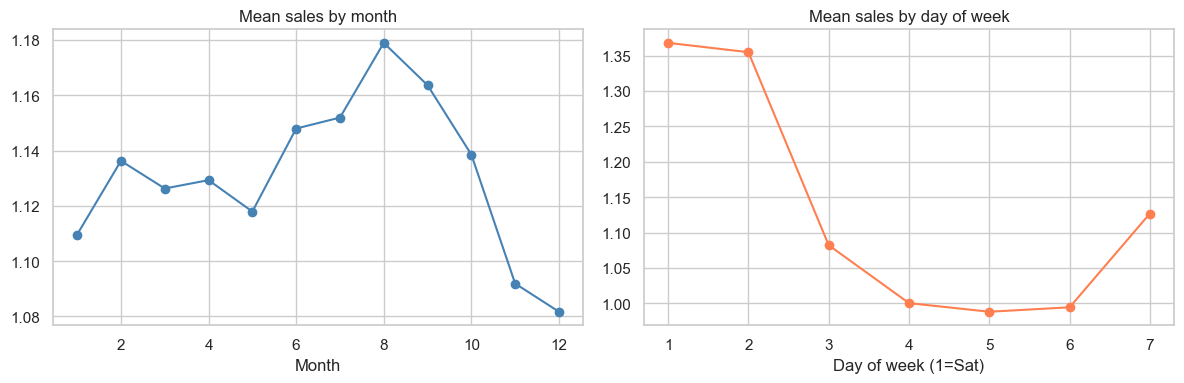

In [19]:
#---SEASONALITY---

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
# Month
df.groupby("month")["sales"].mean().plot(
    ax=axes[0], marker="o", color="steelblue"
)
axes[0].set_title("Mean sales by month")
axes[0].set_xlabel("Month")

# Day of week
df.groupby("wday")["sales"].mean().plot(
    ax=axes[1], marker="o", color="coral"
)
axes[1].set_title("Mean sales by day of week")
axes[1].set_xlabel("Day of week (1=Sat)")

plt.tight_layout()
plt.savefig(OUTPUT / "seasonality.png", dpi=150)
plt.show()

## Nhận xét Seasonality

### Theo tháng (left):
- Biên độ dao động khá hẹp (~1.08–1.18) — seasonality theo tháng
  có tồn tại nhưng không quá mạnh
- **Tháng 8 cao nhất (~1.18)** 
- **Tháng 12 thấp nhất (~1.08)** 
- Tháng 11 giảm đột ngột sau tháng 10 — cần lưu ý khi
  tính feature `month` ở bước feature engineering

### Theo ngày trong tuần (right):
- Pattern rõ ràng hơn nhiều so với theo tháng
- **Thứ 7 và Chủ nhật (wday 1–2) cao nhất (~1.35–1.38)**
  — người đi mua sắm cuối tuần nhiều hơn
- **Thứ 4 và thứ 6 (wday 4–6) thấp nhất (~1.00)**
  — giữa tuần ít mua sắm nhất
- Thứ 7 (wday 7) tăng nhẹ trở lại so với thứ 6

### Kết luận cho feature engineering:
- `day_of_week` là feature mạnh hơn `month` —
  biên độ dao động theo ngày (~38%) lớn hơn nhiều
  so với theo tháng (~9%)
- Cả 2 đều cần giữ lại trong `sales_clean.parquet`
  như spec yêu cầu

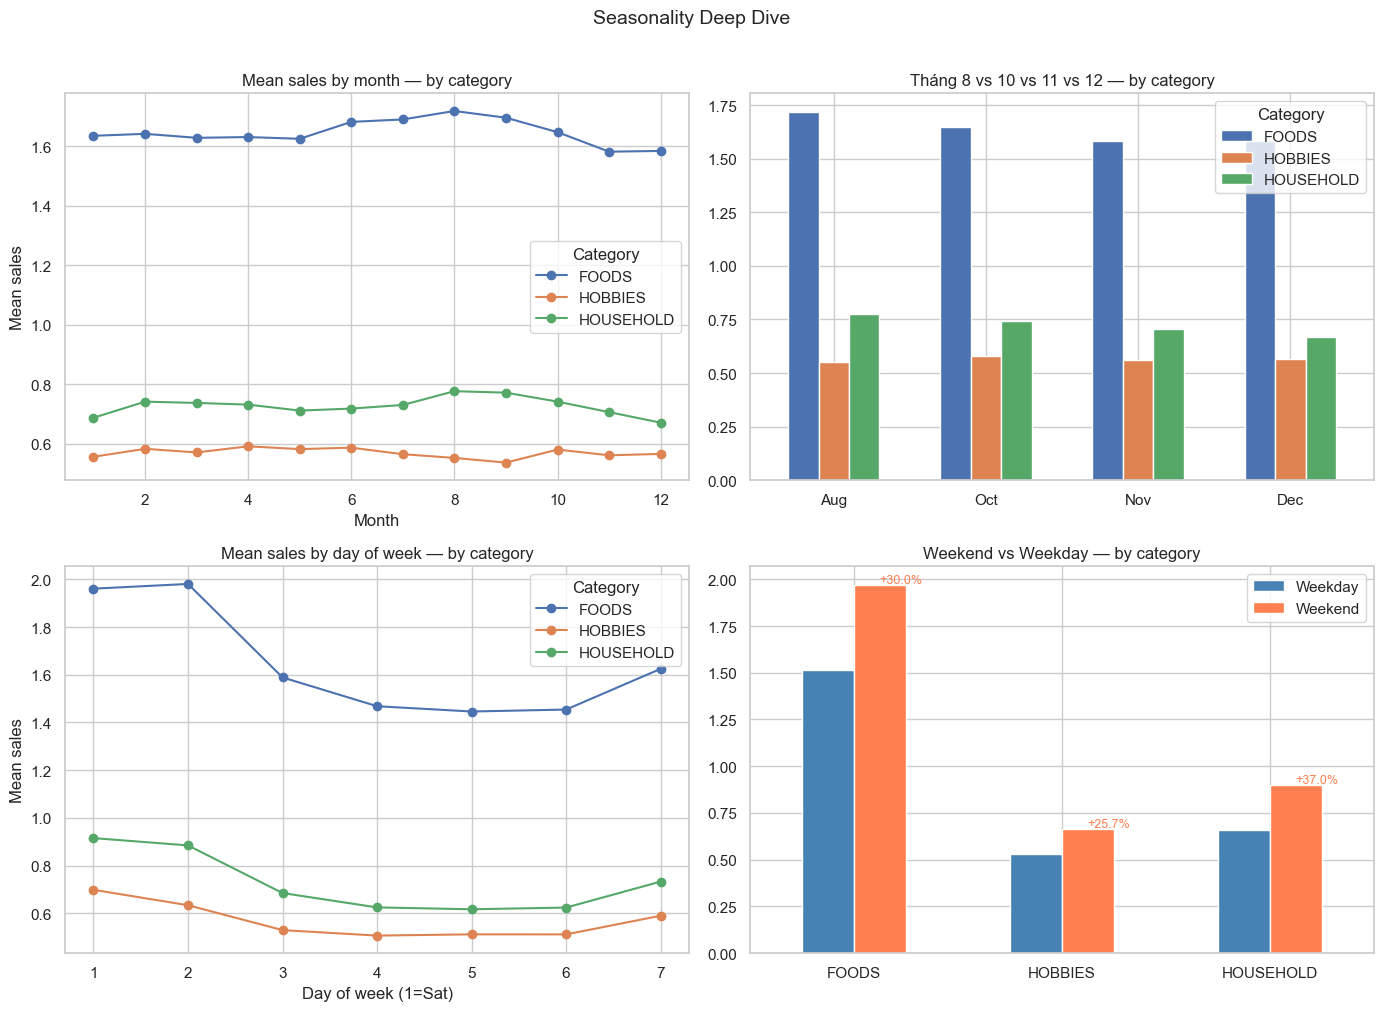


Weekend lift by category:
           Weekday  Weekend  lift_%
cat_id                             
FOODS        1.516    1.971  29.961
HOBBIES      0.530    0.666  25.716
HOUSEHOLD    0.657    0.900  37.021


In [ ]:
#---SEASONALITY DEEP DIVE---

fig, axes = plt.subplots(2, 2, figsize=(14, 10))


df.groupby(["month", "cat_id"])["sales"].mean().unstack().plot(
    ax=axes[0, 0], marker="o"
)
axes[0, 0].set_title("Mean sales by month — by category")
axes[0, 0].set_xlabel("Month")
axes[0, 0].set_ylabel("Mean sales")
axes[0, 0].legend(title="Category")


cat_month = df.groupby(["month", "cat_id"])["sales"].mean().unstack()
cat_month.loc[[8, 10, 11, 12]].plot(
    kind="bar", ax=axes[0, 1], width=0.6
)
axes[0, 1].set_title("Tháng 8 vs 10 vs 11 vs 12 — by category")
axes[0, 1].set_xlabel("")
axes[0, 1].set_xticklabels(
    ["Aug", "Oct", "Nov", "Dec"], rotation=0
)
axes[0, 1].legend(title="Category")


df.groupby(["wday", "cat_id"])["sales"].mean().unstack().plot(
    ax=axes[1, 0], marker="o"
)
axes[1, 0].set_title("Mean sales by day of week — by category")
axes[1, 0].set_xlabel("Day of week (1=Sat)")
axes[1, 0].set_ylabel("Mean sales")
axes[1, 0].legend(title="Category")


df["is_weekend"] = df["wday"].isin([1, 2]).astype(int)
weekend_data = df.groupby(
    ["cat_id", "is_weekend"]
)["sales"].mean().unstack()
weekend_data.columns = ["Weekday", "Weekend"]
weekend_data["lift_%"] = (
    (weekend_data["Weekend"] - weekend_data["Weekday"])
    / weekend_data["Weekday"] * 100
)

weekend_data[["Weekday", "Weekend"]].plot(
    kind="bar", ax=axes[1, 1],
    color=["steelblue", "coral"],
    width=0.5
)
axes[1, 1].set_title("Weekend vs Weekday — by category")
axes[1, 1].set_xlabel("")
axes[1, 1].set_xticklabels(
    weekend_data.index.tolist(), rotation=0
)
axes[1, 1].legend()


for i, (cat, row) in enumerate(weekend_data.iterrows()):
    axes[1, 1].annotate(
        f"+{row['lift_%']:.1f}%",
        xy=(i + 0.12, row["Weekend"] + 0.01),
        fontsize=9, color="coral"
    )

plt.suptitle("Seasonality Deep Dive", fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig(OUTPUT / "seasonality_deep_dive.png", dpi=150,
            bbox_inches="tight")
plt.show()


print("\nWeekend lift by category:")
print(weekend_data.round(3))

## Nhận xét Seasonality Deep Dive

### Theo tháng — by category (top-left + top-right):
- **FOODS dominant hoàn toàn** — mean sales ~1.6–1.7, cao gấp
  3x so với HOBBIES (~0.6) và HOUSEHOLD (~0.7)
- FOODS kéo đường trung bình tổng lên, che khuất pattern
  của 2 category còn lại
- **Tháng 8 cao nhất do FOODS tăng**, HOBBIES và HOUSEHOLD gần như
  không đổi qua các tháng
- **Tháng 12 thấp** được giải thích rõ: HOUSEHOLD giảm mạnh
  (~0.65), FOODS giảm nhẹ (~1.6), HOBBIES ổn định (~0.57)
- Kết luận: seasonality theo tháng chủ yếu đến từ **FOODS**,
  HOBBIES và HOUSEHOLD gần như flat quanh năm

### Theo ngày trong tuần — by category (bottom-left):
- Pattern weekend cao hơn weekday **đồng nhất ở cả 3 category**
- FOODS có biên độ lớn nhất: ~2.0 (Sat) xuống ~1.45 (Thu)
- HOBBIES và HOUSEHOLD có pattern tương tự nhưng biên độ nhỏ hơn
- wday 1–2 (Sat–Sun) luôn là đỉnh, wday 4–6 (Wed–Fri) luôn là đáy

### Weekend lift — by category (bottom-right):
- **HOUSEHOLD cao nhất (+37.0%)** — mua đồ gia dụng
  tập trung cuối tuần rõ rệt nhất
- **FOODS +30.0%** — đi chợ cuối tuần
- **HOBBIES +25.7%** — thấp nhất nhưng vẫn đáng kể

### Kết luận cập nhật cho feature engineering:
- `day_of_week` là feature mạnh và **nhất quán** across categories
  → giữ lại trong schema
- `month` chủ yếu có ý nghĩa với FOODS, ít tác động với
  HOBBIES/HOUSEHOLD → vẫn giữ nhưng weight thấp hơn


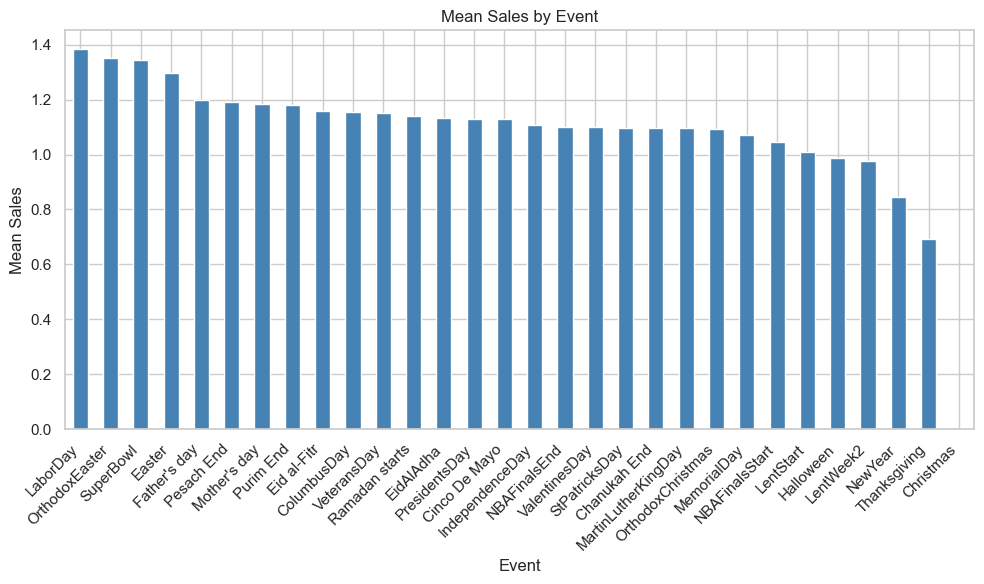

In [20]:
#---EVENT---

event_sales = df.groupby("event_name_1")["sales"].mean().sort_values(ascending=False)
plt.figure(figsize=(10, 6))
event_sales.plot(kind="bar", color="steelblue")
plt.title("Mean Sales by Event")
plt.xlabel("Event")
plt.ylabel("Mean Sales")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig(OUTPUT / "event_sales.png", dpi=150)
plt.show()

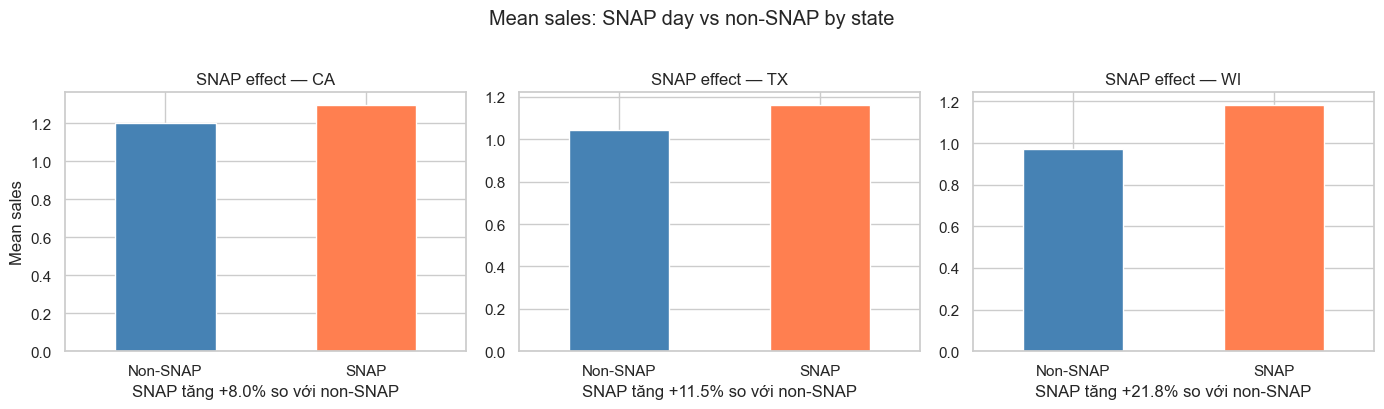

In [ ]:
#---SNAP EFFECT---

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
# So sánh mean sales giữa ngày SNAP và non-SNAP cho từng bang
for ax, state in zip(axes, ["CA", "TX", "WI"]):
    snap_col = f"snap_{state}"
    
    
    state_stores = df[df["state_id"] == state]
    
    snap_effect = state_stores.groupby(snap_col)["sales"].mean()
    
    snap_effect.plot(
        kind="bar",
        ax=ax,
        color=["steelblue", "coral"],
        edgecolor="white",
        width=0.5
    )
    ax.set_title(f"SNAP effect — {state}")
    ax.set_xlabel("")
    ax.set_xticks([0, 1])
    ax.set_xticklabels(["Non-SNAP", "SNAP"], rotation=0)
    ax.set_ylabel("Mean sales" if state == "CA" else "")
    
    # So sánh bằng tỉ lệ
    non_snap = snap_effect.get(0, snap_effect.iloc[0])
    snap_val  = snap_effect.get(1, snap_effect.iloc[1])
    pct = (snap_val - non_snap) / non_snap * 100
    ax.set_xlabel(f"SNAP tăng {pct:+.1f}% so với non-SNAP")

plt.suptitle("Mean sales: SNAP day vs non-SNAP by state", y=1.02)
plt.tight_layout()
plt.savefig(OUTPUT / "snap_effect.png", dpi=150, bbox_inches="tight")
plt.show()

## Nhận xét SNAP Effect

- SNAP day có tác động tích cực đến sales ở cả 3 states,
  mức tăng dao động từ **+8% đến +22%** so với non-SNAP

- **WI tăng mạnh nhất (+21.8%)** — người dùng SNAP ở Wisconsin
  có hành vi mua sắm tập trung hơn vào ngày SNAP

- **CA tăng thấp nhất (+8.0%)** — có thể do CA có nhiều store lớn,
  hành vi mua sắm phân tán hơn, ít phụ thuộc vào ngày SNAP

- **TX ở mức trung bình (+11.5%)**

- Kết luận: cột `snap` là feature có ý nghĩa, cần giữ lại
  trong `sales_clean.parquet` cho bước feature engineering,không phải noise

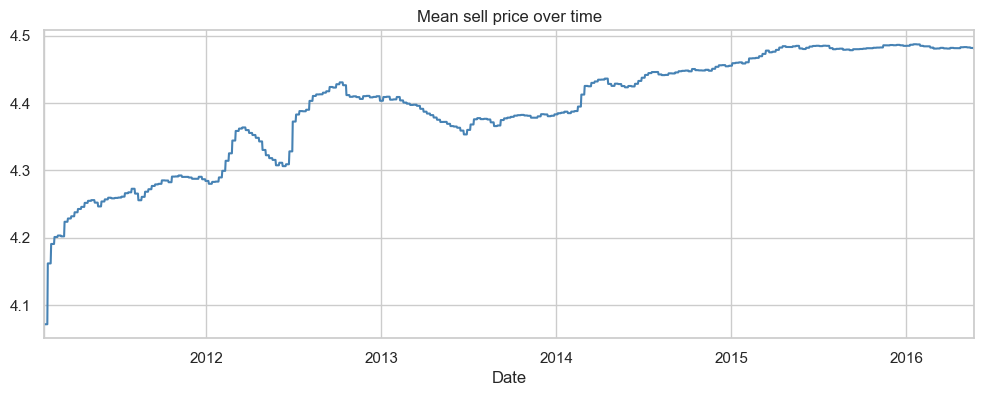

In [22]:
#---PRICE TREND---

price_trend = (
    df.groupby("date")["sell_price"]
    .mean()
    .dropna()
)

plt.figure(figsize=(12, 4))
price_trend.plot(color="steelblue")
plt.title("Mean sell price over time")
plt.xlabel("Date")
plt.savefig(OUTPUT / "price_trend.png", dpi=150)
plt.show()

## Nhận xét Sell Price

- Giá bán có xu hướng **tăng dần theo thời gian** từ ~4.1 (2011)
  lên ~4.9 (2016) — tăng khoảng 20% trong 5 năm

- Có **2 giai đoạn tăng đột biến** rõ rệt:
  - Cuối 2011 → đầu 2012: tăng nhanh từ 4.1 lên 4.4
  - Giữa 2014 → 2015: tăng tiếp từ 4.4 lên 4.6

- Giai đoạn **2013** có dấu hiệu đi ngang, thậm chí giảm nhẹ
  trước khi tăng trở lại vào 2014

- Từ **2015 → 2016** giá ổn định ở mức ~4.8–4.9,
  tốc độ tăng chậm lại đáng kể

- **Kết luận cho bước cleaning**: `sell_price` có missing values
  cần forward-fill within mỗi nhóm (item_id, store_id) theo thời gian —
  hợp lý vì giá thay đổi từ từ, không nhảy đột ngột.
  Tuyệt đối không backward fill vì sẽ gây data leakage
  (dùng giá tương lai để fill giá quá khứ)